<a href="https://colab.research.google.com/github/uday367/deep-learning/blob/main/VGG_16_with_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.9240 - loss: 0.2459 - val_accuracy: 0.9811 - val_loss: 0.0589
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.9808 - loss: 0.0635 - val_accuracy: 0.9770 - val_loss: 0.0739
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.9870 - loss: 0.0394 - val_accuracy: 0.9839 - val_loss: 0.0510


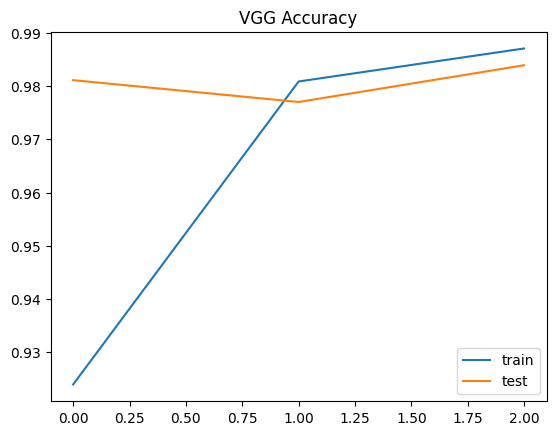

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Use smaller dataset for speed
x_train = x_train[:20000]
y_train = y_train[:20000]

x_train = x_train.reshape(-1,28,28,1)/255.0
x_test = x_test.reshape(-1,28,28,1)/255.0

model = models.Sequential([

    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train,y_train,epochs=3,validation_data=(x_test,y_test))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("VGG Accuracy")
plt.legend(['train','test'])
plt.show()